In [2]:
# Cyber Fraud Analytics
# BharatCares Internship Final Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Year-wise Cyber Fraud Data

year_data = pd.DataFrame({
    "Year": ["2020-21", "2021-22", "2022-23", "2023-24", "2024-25"],
    "Fraud_Cases": [2545, 3596, 6699, 29082, 13384],
    "Amount_Crore": [119, 155, 277, 1457, 534]
})

year_data

,Year,Fraud_Cases,Amount_Crore
0,2020-21,2545,119
1,2021-22,3596,155
2,2022-23,6699,277
3,2023-24,29082,1457
4,2024-25,13384,534


In [4]:
# State-wise Cyber Fraud Data

state_data = pd.DataFrame({
    "State_UT": [
        "Uttar Pradesh", "Maharashtra", "Gujarat", "Rajasthan",
        "Karnataka", "Telangana", "Haryana", "Delhi", "Tamil Nadu",
        "West Bengal", "Bihar", "Andhra Pradesh", "Madhya Pradesh",
        "Kerala", "Odisha", "Punjab", "Chhattisgarh", "Uttarakhand",
        "Jharkhand", "Assam", "Himachal Pradesh", "Jammu & Kashmir",
        "Chandigarh", "Tripura", "Goa", "Puducherry", "Meghalaya",
        "Arunachal Pradesh", "Manipur", "Andaman & Nicobar Islands",
        "Dadra & Nagar Haveli And Daman & Diu", "Nagaland", "Mizoram",
        "Sikkim", "Ladakh", "Lakshadweep"
    ],
    "Total_Incidents": [
        630778,427607,367754,267781,252487,241666,212001,205464,185584,
        153110,149857,113439,105991,83945,75274,75087,63941,61712,
        38632,30821,20503,14476,12399,7143,6052,5255,2517,2246,1992,
        1685,1615,1167,1135,844,505,85
    ],
    "Amount_Reported_Lakh": [
        285875.57,575492.05,274589.93,150912.65,415117.32,333165.59,
        149290.62,194345.27,312596.73,160602.33,82232.92,155989.39,
        79242.97,114292.61,58375.72,74092.69,40559.57,31443.18,
        42667.99,16067.21,18499.14,17566.02,11435.56,4368.21,14906.43,
        8626.79,5230.24,5542.17,3163.44,1388.82,1861.01,1237.05,
        1895.32,1462.01,618.56,66.77
    ],
    "Lien_Amount_Lakh": [
        30610.47,62187.87,55698.11,18338.66,40341.8,46809.74,22713.37,
        18667.93,22650.3,19169.87,12095.07,20378.75,7576.84,16526.08,
        5995.18,10150.78,4806.79,4283.43,7326.73,2017.32,1833.68,
        1545.27,1659.94,461.11,1375.74,547.62,320.72,808.3,386.71,
        113.46,176.51,161.17,177.61,118.86,36.86,11.92
    ],
    "Refunded_Amount_Lakh": [
        382.2,918.83,1031.58,543.4,475.96,610.9,352.47,261.7,172.04,
        210.97,124.49,200.11,78.93,112.59,96.89,142.96,82.62,35.69,
        51.71,27.85,6.64,39.52,7.6,2.47,9.38,51.17,0.93,1.01,8.08,
        0.02,4.3,0,5.55,0.07,1.02,0
    ]
})

state_data.head()

,State_UT,Total_Incidents,Amount_Reported_Lakh,Lien_Amount_Lakh,Refunded_Amount_Lakh
0,Uttar Pradesh,630778,285875.57,30610.47,382.20
1,Maharashtra,427607,575492.05,62187.87,918.83
2,Gujarat,367754,274589.93,55698.11,1031.58
3,Rajasthan,267781,150912.65,18338.66,543.40
4,Karnataka,252487,415117.32,40341.80,475.96


In [5]:
# Data Cleaning and Calculated Columns

year_data = year_data.drop_duplicates().reset_index(drop=True)
state_data = state_data.drop_duplicates().reset_index(drop=True)

# Calculate recovery-related percentages
state_data["Lien_Percent"] = (
    state_data["Lien_Amount_Lakh"] /
    state_data["Amount_Reported_Lakh"] * 100
).round(2)

state_data["Refunded_Percent"] = (
    state_data["Refunded_Amount_Lakh"] /
    state_data["Amount_Reported_Lakh"] * 100
).round(2)

print("Year-wise records:", len(year_data))
print("State/UT records:", len(state_data))

Year-wise records: 5
State/UT records: 36


In [6]:
# Year-wise Analysis

total_fraud_cases = year_data["Fraud_Cases"].sum()
total_amount_crore = year_data["Amount_Crore"].sum()

avg_fraud_cases = year_data["Fraud_Cases"].mean()
avg_amount_crore = year_data["Amount_Crore"].mean()

highest_fraud_year = year_data.loc[
    year_data["Fraud_Cases"].idxmax(), "Year"
]

highest_amount_year = year_data.loc[
    year_data["Amount_Crore"].idxmax(), "Year"
]

print("Total Fraud Cases:", total_fraud_cases)
print("Total Amount Involved (Rs. Crore):", total_amount_crore)
print("Average Fraud Cases per Year:", round(avg_fraud_cases, 2))
print("Average Amount per Year (Rs. Crore):", round(avg_amount_crore, 2))
print("Highest Fraud Cases Year:", highest_fraud_year)
print("Highest Amount Involved Year:", highest_amount_year)

Total Fraud Cases: 55306
Total Amount Involved (Rs. Crore): 2542
Average Fraud Cases per Year: 11061.2
Average Amount per Year (Rs. Crore): 508.4
Highest Fraud Cases Year: 2023-24
Highest Amount Involved Year: 2023-24


In [7]:
# Year-wise Percentage Change

year_data["Fraud_Growth_%"] = (
    year_data["Fraud_Cases"].pct_change() * 100
).round(2)

year_data["Amount_Growth_%"] = (
    year_data["Amount_Crore"].pct_change() * 100
).round(2)

year_data

,Year,Fraud_Cases,Amount_Crore,Fraud_Growth_%,Amount_Growth_%
0,2020-21,2545,119,NaN,NaN
1,2021-22,3596,155,41.30,30.25
2,2022-23,6699,277,86.29,78.71
3,2023-24,29082,1457,334.12,425.99
4,2024-25,13384,534,-53.98,-63.35


In [8]:
# State-wise Analysis

total_incidents = state_data["Total_Incidents"].sum()
total_reported = state_data["Amount_Reported_Lakh"].sum()
total_lien = state_data["Lien_Amount_Lakh"].sum()
total_refunded = state_data["Refunded_Amount_Lakh"].sum()

highest_incidents_state = state_data.loc[
    state_data["Total_Incidents"].idxmax(), "State_UT"
]

highest_reported_state = state_data.loc[
    state_data["Amount_Reported_Lakh"].idxmax(), "State_UT"
]

highest_lien_state = state_data.loc[
    state_data["Lien_Amount_Lakh"].idxmax(), "State_UT"
]

highest_refunded_state = state_data.loc[
    state_data["Refunded_Amount_Lakh"].idxmax(), "State_UT"
]

print("Total Incidents:", total_incidents)
print("Total Amount Reported (Rs. Lakh):", round(total_reported, 2))
print("Total Lien Amount (Rs. Lakh):", round(total_lien, 2))
print("Total Refunded Amount (Rs. Lakh):", round(total_refunded, 2))
print("Highest Incidents State:", highest_incidents_state)
print("Highest Reported Amount State:", highest_reported_state)
print("Highest Lien Amount State:", highest_lien_state)
print("Highest Refunded Amount State:", highest_refunded_state)

Total Incidents: 3822550
Total Amount Reported (Rs. Lakh): 3644819.85
Total Lien Amount (Rs. Lakh): 438080.57
Total Refunded Amount (Rs. Lakh): 6051.65
Highest Incidents State: Uttar Pradesh
Highest Reported Amount State: Maharashtra
Highest Lien Amount State: Maharashtra
Highest Refunded Amount State: Gujarat


In [10]:
# Top 5 States/UTs Analysis

top_incidents = state_data.nlargest(5, "Total_Incidents")[
    ["State_UT", "Total_Incidents"]
]

top_amount = state_data.nlargest(5, "Amount_Reported_Lakh")[
    ["State_UT", "Amount_Reported_Lakh"]
]

top_lien = state_data.nlargest(5, "Lien_Percent")[
    ["State_UT", "Lien_Percent"]
]

top_refund = state_data.nlargest(5, "Refunded_Percent")[
    ["State_UT", "Refunded_Percent"]
]

print("Top 5 States by Incidents")
display(top_incidents)

print("Top 5 States by Amount Reported")
display(top_amount)

print("Top 5 States by Lien %")
display(top_lien)

print("Top 5 States by Refunded %")
display(top_refund)

Top 5 States by Incidents


,State_UT,Total_Incidents
0,Uttar Pradesh,630778
1,Maharashtra,427607
2,Gujarat,367754
3,Rajasthan,267781
4,Karnataka,252487


Top 5 States by Amount Reported


,State_UT,Amount_Reported_Lakh
1,Maharashtra,575492.05
4,Karnataka,415117.32
5,Telangana,333165.59
8,Tamil Nadu,312596.73
0,Uttar Pradesh,285875.57


Top 5 States by Lien %


,State_UT,Lien_Percent
2,Gujarat,20.28
35,Lakshadweep,17.85
18,Jharkhand,17.17
6,Haryana,15.21
10,Bihar,14.71


Top 5 States by Refunded %


,State_UT,Refunded_Percent
25,Puducherry,0.59
2,Gujarat,0.38
3,Rajasthan,0.36
32,Mizoram,0.29
28,Manipur,0.26


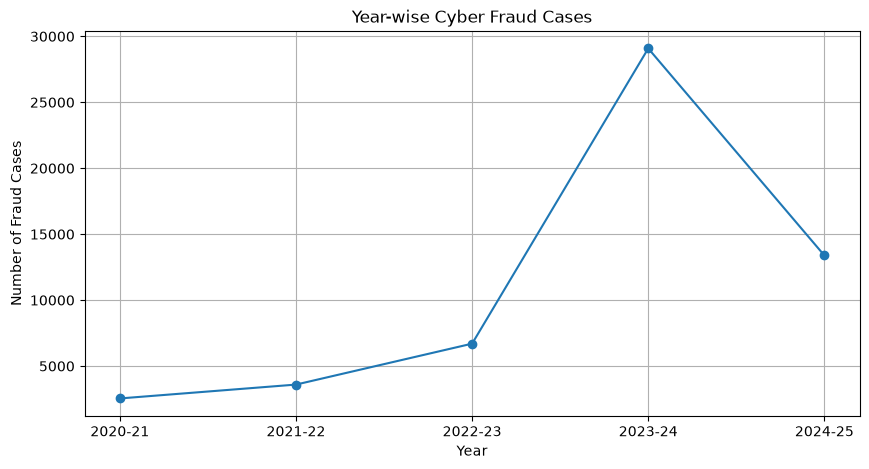

In [11]:
# Year-wise Fraud Cases Trend

plt.figure(figsize=(10, 5))
plt.plot(
    year_data["Year"],
    year_data["Fraud_Cases"],
    marker="o"
)

plt.title("Year-wise Cyber Fraud Cases")
plt.xlabel("Year")
plt.ylabel("Number of Fraud Cases")
plt.grid(True)
plt.show()

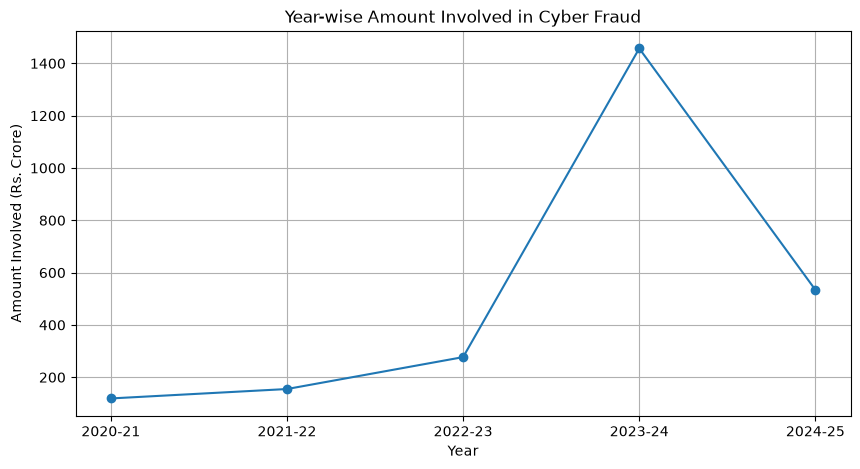

In [12]:
# Year-wise Amount Involved Trend

plt.figure(figsize=(10, 5))
plt.plot(
    year_data["Year"],
    year_data["Amount_Crore"],
    marker="o"
)

plt.title("Year-wise Amount Involved in Cyber Fraud")
plt.xlabel("Year")
plt.ylabel("Amount Involved (Rs. Crore)")
plt.grid(True)
plt.show()

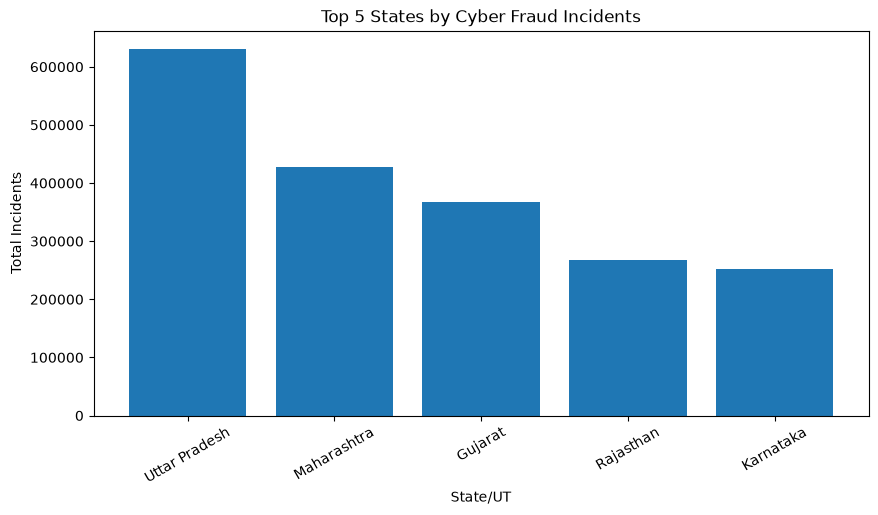

In [13]:
# Top 5 States by Cyber Fraud Incidents

plt.figure(figsize=(10, 5))
plt.bar(
    top_incidents["State_UT"],
    top_incidents["Total_Incidents"]
)

plt.title("Top 5 States by Cyber Fraud Incidents")
plt.xlabel("State/UT")
plt.ylabel("Total Incidents")
plt.xticks(rotation=30)
plt.show()

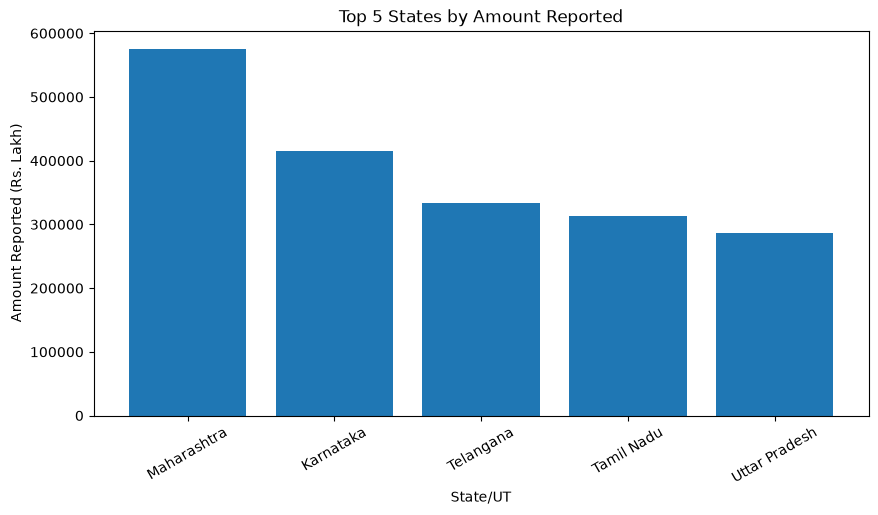

In [14]:
# Top 5 States by Amount Reported

plt.figure(figsize=(10, 5))
plt.bar(
    top_amount["State_UT"],
    top_amount["Amount_Reported_Lakh"]
)

plt.title("Top 5 States by Amount Reported")
plt.xlabel("State/UT")
plt.ylabel("Amount Reported (Rs. Lakh)")
plt.xticks(rotation=30)
plt.show()

In [15]:
# Key Insights from the Analysis

print("KEY INSIGHTS")
print("-" * 50)

print("1. The highest number of fraud cases was recorded in 2023-24.")
print("2. The highest amount involved was also recorded in 2023-24.")
print("3. Uttar Pradesh recorded the highest total number of incidents among States/UTs.")
print("4. Maharashtra recorded the highest amount reported among States/UTs.")
print("5. Maharashtra also recorded the highest lien amount.")
print("6. Gujarat recorded the highest refunded percentage among the listed States/UTs.")
print("7. Fraud cases decreased by 53.98% in 2024-25 compared with 2023-24.")
print("8. The analysis shows significant variation in cyber fraud incidents and financial recovery across States/UTs.")

KEY INSIGHTS
--------------------------------------------------
1. The highest number of fraud cases was recorded in 2023-24.
2. The highest amount involved was also recorded in 2023-24.
3. Uttar Pradesh recorded the highest total number of incidents among States/UTs.
4. Maharashtra recorded the highest amount reported among States/UTs.
5. Maharashtra also recorded the highest lien amount.
6. Gujarat recorded the highest refunded percentage among the listed States/UTs.
7. Fraud cases decreased by 53.98% in 2024-25 compared with 2023-24.
8. The analysis shows significant variation in cyber fraud incidents and financial recovery across States/UTs.


In [16]:
# Business Recommendations

print("BUSINESS RECOMMENDATIONS")
print("-" * 50)

print("1. Focus cyber-fraud prevention efforts on States with high incident volumes.")
print("2. Prioritize monitoring in regions reporting high financial losses.")
print("3. Strengthen early detection and lien mechanisms to prevent further loss of funds.")
print("4. Improve coordination between banks, law-enforcement agencies and cyber-fraud reporting systems.")
print("5. Increase public awareness about digital payment fraud and safe online practices.")
print("6. Use data-driven monitoring to identify changes in fraud trends and emerging risk areas.")

BUSINESS RECOMMENDATIONS
--------------------------------------------------
1. Focus cyber-fraud prevention efforts on States with high incident volumes.
2. Prioritize monitoring in regions reporting high financial losses.
3. Strengthen early detection and lien mechanisms to prevent further loss of funds.
4. Improve coordination between banks, law-enforcement agencies and cyber-fraud reporting systems.
5. Increase public awareness about digital payment fraud and safe online practices.
6. Use data-driven monitoring to identify changes in fraud trends and emerging risk areas.


In [17]:
# Project Conclusion

print("PROJECT CONCLUSION")
print("-" * 50)

print("This analysis provides a data-driven view of cyber fraud trends")
print("across years and States/UTs. The analysis identifies changes in")
print("fraud cases, financial losses, lien amounts and refunded amounts.")
print("These insights can support better monitoring, fraud prevention,")
print("financial recovery and cyber-awareness initiatives.")

PROJECT CONCLUSION
--------------------------------------------------
This analysis provides a data-driven view of cyber fraud trends
across years and States/UTs. The analysis identifies changes in
fraud cases, financial losses, lien amounts and refunded amounts.
These insights can support better monitoring, fraud prevention,
financial recovery and cyber-awareness initiatives.
